In [2]:
import os
from typing import TypedDict, List, Dict, Any, Optional, Literal
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, RemoveMessage
from typing_extensions import Literal
from langgraph.graph import MessagesState
from pydantic import BaseModel, Field


In [18]:
from IPython.display import display, Image

In [ ]:
memory = SqliteSaver(conn)

In [3]:
#An State Object that we will pass around our nodes, the object is a dictionary
class State(TypedDict):
    # 

    """name: list[str]  # Contains firstname, lastname, middlename

    # The email being collected
    email: str

    # The phone numer being collected
    phone_no: int

    # what customer wants to do
    request: str"""

    user_input: str  #State has one key called user_input
    first_name: Optional[str]
    middle_name: Optional[str]
    last_name: Optional[str]
    email: Optional[str]
    #Conversation
    messages: list

    # Field currently being collected
    current_field: str

    # Value proposed to the user
    proposed_value: str

    # User's latest response
    user_response: str

    # Confirmation result
    confirmation_decision: str

    # If user corrected the value
    corrected_value: Optional[str]

    # Collected user data
    user_data: dict

    # Where to go after confirmation
    next_field: Optional[str]

    # Previous node to return to
    previous_node: Optional[str]

    # Routing result
    route: Optional[str]

In [58]:
import sqlite3

#Connect to a database
connection = sqlite3.connect("Onboardingg.db")

# Create a cursor object to execute SQL commands
cursor = connection.cursor()

#Create a table (if it doesn't already exist)
cursor.execute(
    """
    CREATE TABLE IF NOT EXISTS profile (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        first_name TEXT,
        last_name TEXT,
        middle_name TEXT,
        phone_number INTEGER,
        email_address TEXT,
        customer_request TEXT
    )
"""
)

In [4]:
sys_msg = SystemMessage(
    content = """You are a confirmation classifier in a conversational workflow.

Your ONLY task is to determine whether the user's latest response
confirms, rejects, corrects, or is unclear regarding the value that
the assistant previously presented for confirmation.

The user may respond naturally and does not need to use explicit
words such as "yes" or "no".

Classify the response into exactly one of these categories:

CONFIRMED:
The user clearly indicates that the previously presented value is correct.

Examples:
- "Yes"
- "Yes, that's correct"
- "That's right"
- "Correct"
- "Yep"
- "That's my email"
- "You got it"
- "Sure"
- "Right"
- "Exactly"
- "That's fine"
- "Looks good"

REJECTED:
The user clearly indicates that the previously presented value is incorrect,
but does not provide a replacement value.

Examples:
- "No"
- "No, that's wrong"
- "That's incorrect"
- "That's not right"
- "Wrong"
- "Nope"
- "That's not my email"



UNCLEAR:
The user's response does not provide enough information to determine
whether they confirmed or rejected the proposed value.

Examples:
- "I'm not sure"
- "What?"
- "Which one?"
- "Can you repeat that?"
- "Hmm"
- "Maybe"
- "I don't understand"

Important rules:

1. Evaluate the user's response against the specific proposed value.
2. "Yes", "sure", "right", "correct", "exactly", and similar expressions
   should normally be CONFIRMED when they clearly respond to the
   confirmation request.
3. A response that rejects the proposed value without a replacement is
   REJECTED.
4. Do not infer confirmation when the user's meaning is genuinely ambiguous.
5. Do not modify, normalize, or invent the user's corrected value.
6. Return ONLY the structured classification.

"""
)

In [1]:
CONFIRMATION_SYSTEM_PROMPT = """
You are a confirmation classifier in a conversational workflow.

Your ONLY task is to determine whether the user's latest response
confirms, rejects, corrects, or is unclear regarding the value that
the assistant previously presented.

The user may respond naturally.

Classify the response into exactly one of:

CONFIRMED:
The user clearly indicates that the proposed value is correct.

Examples:
- "Yes"
- "Yes, that's correct"
- "That's right"
- "Correct"
- "Yep"
- "That's my email"
- "You got it"
- "Sure"
- "Right"
- "Exactly"
- "Looks good"

REJECTED:
The user indicates that the proposed value is wrong,
but does not provide a replacement.

Examples:
- "No"
- "That's wrong"
- "That's incorrect"
- "Nope"
- "That's not right"
- "Wrong"

CORRECTED:
The user rejects the proposed value AND provides a replacement.

Examples:
- "No, my email is john123@gmail.com"
- "Actually, my name is John Smith"
- "No, my number is 415-555-1234"

When the user provides a correction, extract the replacement
value into corrected_value.

UNCLEAR:
There is not enough information to determine whether the user
confirmed or rejected the proposed value.

Examples:
- "Hmm"
- "I'm not sure"
- "What?"
- "Which one?"
- "Can you repeat that?"
- "Maybe"

Rules:

1. Evaluate the response against the specific proposed value.
2. Do not assume confirmation when the meaning is ambiguous.
3. A simple "yes", "correct", "right", "sure", etc. is CONFIRMED
   when it clearly answers the confirmation question.
4. A rejection with no replacement is REJECTED.
5. A rejection with a replacement is CORRECTED.
6. Do not invent or modify a corrected value.
7. Return only the structured classification.
"""

In [5]:
class ConfirmationResult(BaseModel):
    decision: Literal[
        "CONFIRMED",
        "REJECTED",
        "CORRECTED",
        "UNCLEAR"
    ] = Field(
        description="The classification of the user's response."
    )

    corrected_value: Optional[str] = Field(
        default=None,
        description=(
            "The replacement value provided by the user. "
            "Only populate this when the user provides a correction."
        )
    )

In [6]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature = 0)

confirmation_llm = llm.with_structured_output(
    ConfirmationResult
)

In [44]:
def confirmation_input(state:State):
    user_response = input(f"please confirm that this correct: {state['proposed_value']}\nYour response: ")
    return {
    "user_input": state["user_input"],
    "current_field": "name",
    "proposed_value": state["proposed_value"],
    "user_response": user_response
    }


In [38]:
def confirmation_node(state: State):

    current_field = state["current_field"]
    proposed_value = state["proposed_value"]
    user_response = state["user_response"]
    print(user_response)

    prompt = f"""
    Field being confirmed:
    {current_field}

    Proposed value:
    {proposed_value}

    User's response:
    {user_response}

    Determine the appropriate confirmation decision.
    """

    result = confirmation_llm.invoke([
        {
            "role": "system",
            "content": CONFIRMATION_SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": prompt
        }
    ])

    return {
        "confirmation_decision": result.decision,
        "corrected_value": result.corrected_value
    }

In [8]:
def route_confirmation(state: State):

    decision = state["confirmation_decision"]

    if decision == "CONFIRMED":
        return "next"

    elif decision == "REJECTED":
        return "previous"

    elif decision == "CORRECTED":
        return "corrected"

    elif decision == "UNCLEAR":
        return "clarify"

    else:
        raise ValueError(
            f"Unknown confirmation decision: {decision}"
        )

In [9]:
def next_node(state: State):

    field = state["current_field"]
    value = state["proposed_value"]

    user_data = state.get("user_data", {}).copy()

    user_data[field] = value

    print(f"Confirmed {field}: {value}")

    return {
        "user_data": user_data
    }

In [10]:
def previous_node(state: State):

    field = state["current_field"]

    print(
        f"User rejected the proposed {field}. "
        f"Returning to collection."
    )

    return {}

In [11]:
def collect_previous_value(state: State):

    field = state["current_field"]

    return {
        "messages": [
            {
                "role": "assistant",
                "content": f"Sure. Please provide your {field} again."
            }
        ]
    }

In [12]:
def corrected_node(state: State):

    corrected_value = state["corrected_value"]

    print(
        f"User provided corrected value: {corrected_value}"
    )

    return {
        "proposed_value": corrected_value
    }

In [13]:
def validate_corrected_value(state: State):

    field = state["current_field"]
    value = state["proposed_value"]

    if field == "email":

        if "@" not in value:
            return {
                "messages": [
                    {
                        "role": "assistant",
                        "content": "That doesn't look like a valid email. Please provide it again."
                    }
                ]
            }

    return {}

In [14]:
def clarify_node(state: State):

    field = state["current_field"]
    proposed_value = state["proposed_value"]

    return {
        "messages": [
            {
                "role": "assistant",
                "content": (
                    f"Just to confirm, is your {field} "
                    f"{proposed_value}? Please say yes or no."
                )
            }
        ]
    }

In [21]:
# Initialize our LLM

from dotenv import load_dotenv
load_dotenv()



from dotenv import load_dotenv
load_dotenv()

# Initialize our LLM


def call_llm(state: State):
    response = llm.invoke([sys_msg] + [HumanMessage(content=state["user_input"])])
    return {"output": response.content}

def take_input(state):
    state["user_input"] = input("Hi there! I am Jeff, what can I do for you today?")
    return {"user_input": state["user_input"]} 

def get_name(state):
    state["user_input"] = input("Please provide your name in this order and format: Firstname Middlename, Lastname. Thanks! ")
    first_name, middle_name, last_name = (state["user_input"]).split()
    state["first_name"] = first_name
    state["middle_name"] = middle_name
    state["last_name"] = last_name
    print(f"confirm your name is: \n firstname :{first_name} \n middlename :{middle_name} \n lastname :{last_name}")
    return {
    "user_input": state["user_input"],
    "current_field": "name",
    "proposed_value": state["user_input"],
    "user_response": state["user_input"],
    "user_data": {
        "first_name": first_name,
        "middle_name": middle_name,
        "last_name": last_name,
    },
}
    #return{"user_input": state["user_input"], "first_name": state["first_name"], "last_name": state["last_name"], "middle_name": state["middle_name"]}

def welcome(state):
    prompt = f""" You are acting as an onboarding agent. You will welcome the customer by saying:
               Hi there! I am Jeff, Trust you are good! Firstly, let me get your details whats your name, provide it in this order and format: Firstname Middlename Lastname."""
    print("\n")
    print("Hi there! I am Jeff, Trust you are good! Firstly, let me get your details whats your name, provide it in this order: First name Last name Middle name. Thanks!")

#def split_name(state):
    #first_name, middle_name, last_name = (state["user_input"]).split()
    #state["first_name"] = first_name
    #state["middle_name"] = middle_name
    #state["last_name"] = last_name
    #print(f"confirm your name is: {first_name}, {last_name}, {middle_name}")
    #return{"user_input": state["user_input"], "first_name": state["first_name"], "last_name": state["last_name"], "middle_name": state["middle_name"]}

#def confirmation(state):
    #confirm = input("Please confirm your details are correct (yes/no): ")
    #if confirm.lower() == yes:
        #return
    #if confirm.lower() == no:


def get_email(state):
    email =input("Please provide your email address: ")
    state["email"] = email
    print(f"confirm your email is: {email}")
    return {"email": state["email"]}

def get_phone_number(state):
    phone_number = input("Please provide your phone number: ")
    state["phone_number"] = phone_number
    print(f"confirm your phone number is: {phone_number}")
    return {"phone_number": state["phone_number"]}

def get_customer_request(state):
    request = input("Please provide your request: ")
    state["request"] = request
    print(f"confirm your request is: {request}")
    return {"request": state["request"]}


def execute_query(query, params=()):
    with sqlite3.connect("Onboardingg.db") as conn:
        cursor = conn.cursor()
        cursor.execute(query, params)
        conn.commit()



def insert_profile_to_db(state):
    query = f"INSERT INTO profile (first_name, middle_name, last_name, email_address, phone_number, customer_request) VALUES (?, ?, ?, ?, ?, ?)"
    params = (state.get("first_name"), state.get("middle_name"), state.get("last_name"), state.get("email"), state.get("phone_number"), state.get("request"))
    print(query)
    execute_query(query, params)
    return state




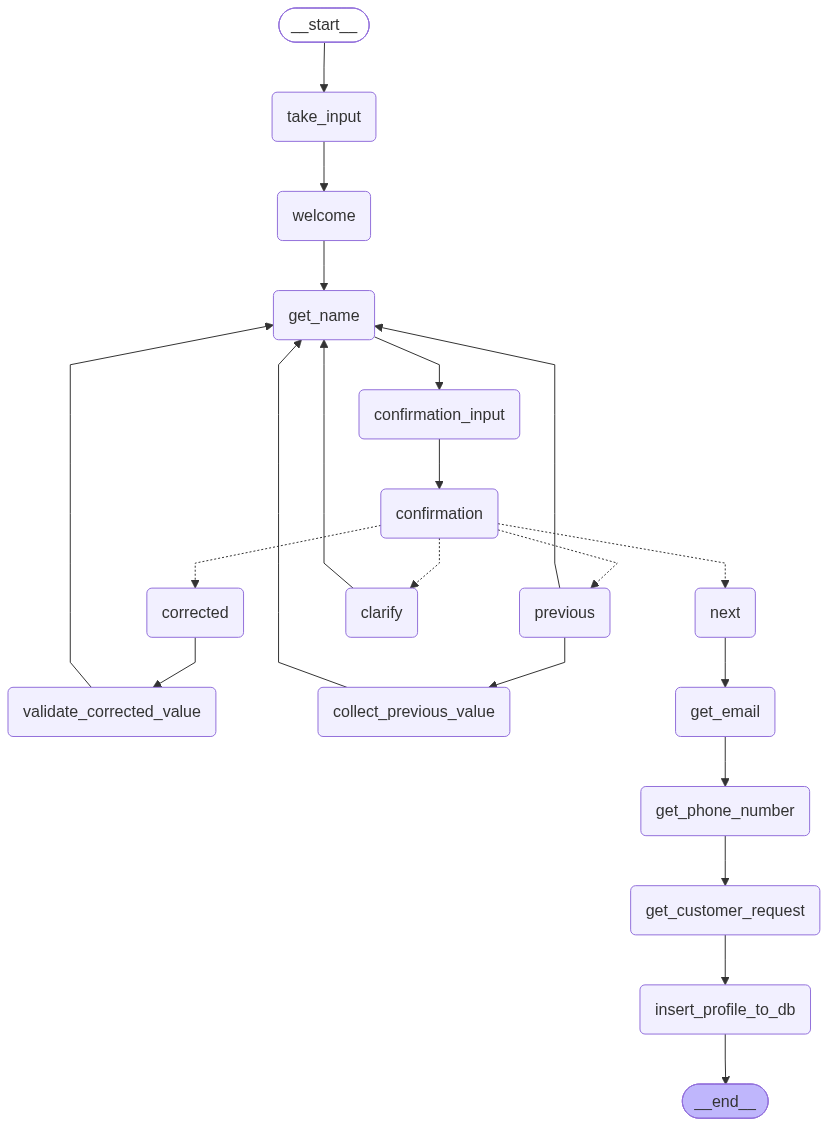

In [47]:
onboard_graph = StateGraph(State)

# Start the edges
onboard_graph.add_node("take_input", take_input)
onboard_graph.add_node("welcome", welcome)
onboard_graph.add_node("get_name", get_name)
# Add nodes
onboard_graph.add_node("confirmation",confirmation_node)
onboard_graph.add_node("confirmation_input", confirmation_input)

onboard_graph.add_node("next",next_node)

onboard_graph.add_node("previous",previous_node)

onboard_graph.add_node("corrected",corrected_node)
onboard_graph.add_node("validate_corrected_value", validate_corrected_value)
onboard_graph.add_node('collect_previous_value', collect_previous_value)

onboard_graph.add_node("clarify",clarify_node)
onboard_graph.add_node("get_email", get_email)
onboard_graph.add_node("get_phone_number", get_phone_number)
onboard_graph.add_node("get_customer_request", get_customer_request)
##onboard_graph.add_node("execute_query", execute_query)
onboard_graph.add_node("insert_profile_to_db", insert_profile_to_db)


onboard_graph.add_edge(START, "take_input")
onboard_graph.add_edge("take_input", "welcome")
onboard_graph.add_edge("welcome", "get_name")
onboard_graph.add_edge("get_name", "confirmation_input")
onboard_graph.add_edge("confirmation_input", "confirmation")
onboard_graph.add_conditional_edges(
    "confirmation",
    route_confirmation,
    {
        "next": "next",
        "previous": "previous",
        "corrected": "corrected",
        "clarify": "clarify"
    }
)

onboard_graph.add_edge("previous", "collect_previous_value")
onboard_graph.add_edge("collect_previous_value", "get_name")
onboard_graph.add_edge("previous", "get_name")


onboard_graph.add_edge("corrected", "validate_corrected_value")
onboard_graph.add_edge("validate_corrected_value", "get_name")
onboard_graph.add_edge("clarify", "get_name")
#onboard_graph.add_edge("get_name", "get_email")

onboard_graph.add_edge("next", "get_email")


onboard_graph.add_edge("get_email", "get_phone_number")
onboard_graph.add_edge("get_phone_number", "get_customer_request")
##onboard_graph.add_edge("get_customer_request", "execute_query")
##onboard_graph.add_edge("execute_query", "insert_profile_to_db")
onboard_graph.add_edge("get_customer_request", "insert_profile_to_db")
onboard_graph.add_edge("insert_profile_to_db", END)
compiled_graph = onboard_graph.compile()

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [49]:
customer_input = "Hi there"
result = compiled_graph.invoke({"user_input":customer_input})



Hi there! I am Jeff, Trust you are good! Firstly, let me get your details whats your name, provide it in this order: First name Last name Middle name. Thanks!
confirm your name is: 
 firstname :a 
 middlename :m 
 lastname :l
no
User rejected the proposed name. Returning to collection.
confirm your name is: 
 firstname :a 
 middlename :s 
 lastname :l


: 

In [ ]:

""""
def get_name(state: OnboardState):
      prompt = f"""You are acting as an onboarding agent. You will onboard new users by getting their names. Ask them to provide their name in this order and format: First name Last name Middle name."""


def write_to_database():
    cursor.execute(
    "INSERT INTO profile (first_name) VALUES (?)", 
    (user_input[0].lstrip())"""

In [8]:
n = "O'meara Lawal Michael"

In [13]:
first, second, third  = n.split()
print(first, "/", second, third)

O'meara / Lawal Michael
